<a href="https://colab.research.google.com/github/vrundagawade151-crypto/CSL701-CS19-Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/ML_prac2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Vrunda Vidyadhar Gawade

Roll No:CS19

**Aim:** To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


**Objectives:**


*   Understand SLR
*   Load/preprocess dataset
*   Perform EDA
*   Compute OLS coefficients
*   Evaluate with SSE, MSE, R²
*   Visualize regression and residual plots








**Software Requirements:**

*   Python 3.x
*   Jupyter/Colab/VS Code
*   Libraries: pandas, numpy, matplotlib, seaborn







**Theory:**



Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:

yˆ=w0+w1x1


In matrix form, including the bias/intercept term X0=1:


yˆ=Xw


To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:


SSE=i=1Nyi-yˆi2=y-XwTy-Xw


Solving for w analytically yields the normal equation:


wˆ=XTX-1XTy


Note: The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant is non-zero).


**Algorithm:**
1.  Import libraries
2.  Load Auto MPG dataset
1.  Inspect and clean data
1.  Select horsepower and mpg
2.  Plot scatter graph
2.  Add bias term
1.  Compute correlation
1.  Calculate OLS weights
1.  Predict values
1.  Compute residuals
2.  Calculate SSE, MSE, R²
2.  Plot regression and residual graphs
2.  Interpret results.
2.  Upload the google colab onto Git hub repository.







**Source Code & Output:**

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Step 2: Load Auto MPG Dataset
df=pd.read_csv("auto-mpg.csv")

In [6]:
print("First 5 Records:")
print(df.head())

First 5 Records:
  horsepower   mpg
0        130  18.0
1        165  15.0
2        150  18.0
3        150  16.0
4        140  17.0


In [8]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   horsepower  398 non-null    object 
 1   mpg         398 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB
None


In [10]:
# Step 3: Inspect and Clean Data
df = df[['horsepower', 'mpg']]
df = df.dropna()

In [12]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df.dropna(subset=['horsepower'], inplace=True)
print("\nCleaned Dataset:")
print(df.head())


Cleaned Dataset:
   horsepower   mpg
0       130.0  18.0
1       165.0  15.0
2       150.0  18.0
3       150.0  16.0
4       140.0  17.0


In [13]:
# Step 4: Select Horsepower and MPG
X = df['horsepower'].values
Y = df['mpg'].values

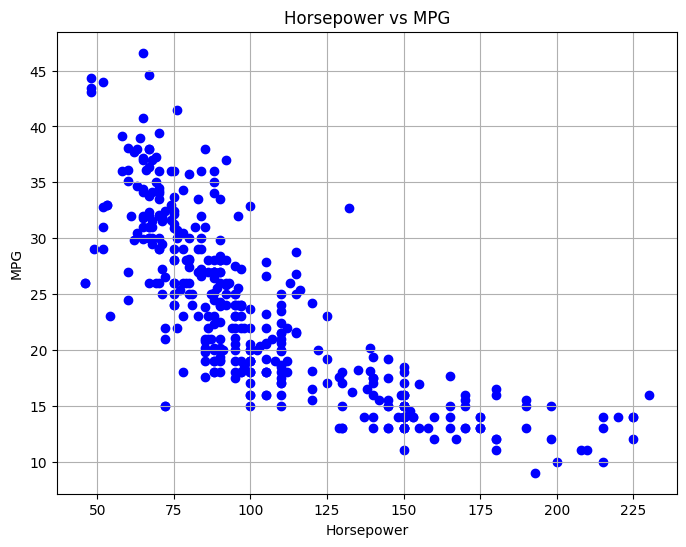

In [14]:
# Step 5: Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.grid(True)
plt.show()


In [15]:
# Step 6: Add Bias Term

X_bias = np.column_stack((np.ones(len(X)), X))


In [16]:
# Step 7: Compute Correlation

correlation = np.corrcoef(X, Y)[0,1]
print("\nCorrelation Coefficient:", correlation)



Correlation Coefficient: -0.7784267838977756


In [17]:
# Step 8: Calculate OLS Weights
# W = (XᵀX)^(-1) XᵀY

weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

intercept = weights[0]
slope = weights[1]

print("\nIntercept (β0):", intercept)
print("Slope (β1):", slope)



Intercept (β0): 39.9358610211705
Slope (β1): -0.15784473335365387


In [18]:
# Step 9: Predict Values

Y_pred = X_bias @ weights

print("\nFirst 10 Predictions:")
print(Y_pred[:10])


First 10 Predictions:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [19]:
# Step 10: Compute Residuals

residuals = Y - Y_pred

In [20]:
# Step 11: Calculate SSE, MSE, R²

SSE = np.sum(residuals**2)

MSE = SSE / len(Y)

SST = np.sum((Y - np.mean(Y))**2)

R2 = 1 - (SSE/SST)

print("\nPerformance Metrics")
print("------------------------")
print("SSE :", SSE)
print("MSE :", MSE)
print("R² Score :", R2)


Performance Metrics
------------------------
SSE : 9385.915871932419
MSE : 23.943662938603108
R² Score : 0.6059482578894348


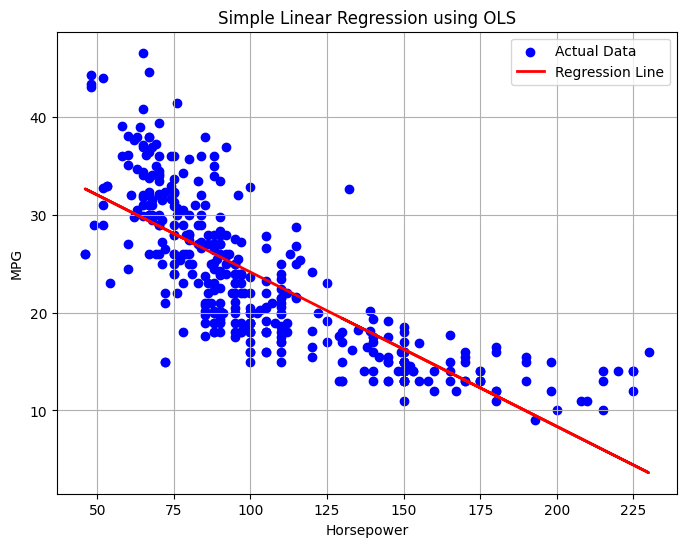

In [21]:
# Step 12: Plot Regression Line

plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression using OLS")
plt.legend()
plt.grid(True)
plt.show()

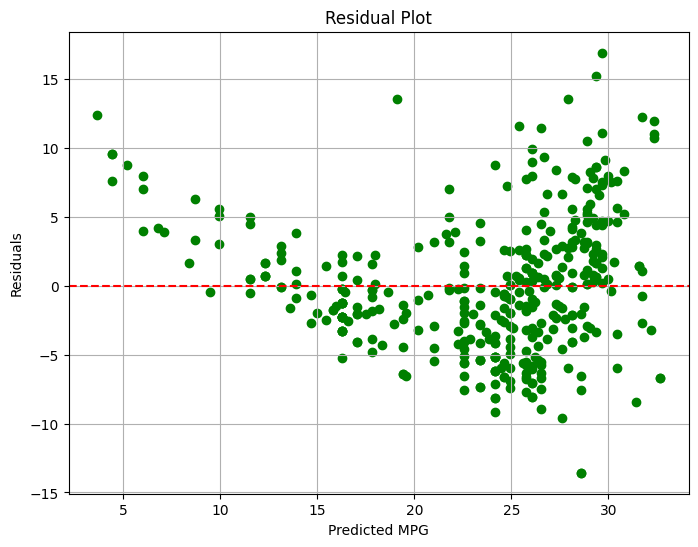

In [22]:
# Step 13: Residual Plot

plt.figure(figsize=(8,6))
plt.scatter(Y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [23]:
# Step 14: Interpretation

print("\nInterpretation")
print("---------------")

if slope < 0:
    print("• Horsepower and MPG have a negative relationship.")
    print("• As Horsepower increases, MPG decreases.")
else:
    print("• Horsepower and MPG have a positive relationship.")

print(f"• Correlation = {correlation:.4f}")

print(f"• R² Score = {R2:.4f}")

if R2 > 0.8:
    print("• The regression model explains most of the variation in MPG.")
elif R2 > 0.6:
    print("• The regression model provides a reasonably good fit.")
else:
    print("• The regression model has a weak fit.")


Interpretation
---------------
• Horsepower and MPG have a negative relationship.
• As Horsepower increases, MPG decreases.
• Correlation = -0.7784
• R² Score = 0.6059
• The regression model provides a reasonably good fit.


**Conclusion**

The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
